In [1]:
!pip install gymnasium torch numpy matplotlib

In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("State size:", state_dim)
print("Action size:", action_dim)

State size: 4
Action size: 2


In [6]:
GAMMA = 0.99
LR = 0.001
BATCH_SIZE = 64
MEMORY_SIZE = 10000

EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01

TARGET_UPDATE = 10
EPISODES = 200

In [7]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [8]:
memory = deque(maxlen=MEMORY_SIZE)

def store_transition(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

In [9]:
policy_net = DQN().to(device)
target_net = DQN().to(device)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.MSELoss()

In [10]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state = torch.FloatTensor(state).unsqueeze(0)
        return torch.argmax(policy_net(state)).item()

In [11]:
def train():
    if len(memory) < BATCH_SIZE:
        return

    batch = random.sample(memory, BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states))
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(np.array(next_states))
    dones = torch.FloatTensor(dones)

    current_q = policy_net(states).gather(1, actions).squeeze()
    next_q = target_net(next_states).max(1)[0]

    target_q = rewards + GAMMA * next_q * (1 - dones)

    loss = loss_fn(current_q, target_q.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [12]:
rewards_list = []
epsilon = EPSILON

for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0

    while True:
        action = select_action(state, epsilon)
        next_state, reward, done, _, _ = env.step(action)

        store_transition(state, action, reward, next_state, done)
        train()

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_list.append(total_reward)

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode: {episode}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode: 0, Reward: 21.0, Epsilon: 0.995
Episode: 1, Reward: 18.0, Epsilon: 0.990
Episode: 2, Reward: 17.0, Epsilon: 0.985
Episode: 3, Reward: 30.0, Epsilon: 0.980
Episode: 4, Reward: 22.0, Epsilon: 0.975
Episode: 5, Reward: 10.0, Epsilon: 0.970
Episode: 6, Reward: 19.0, Epsilon: 0.966
Episode: 7, Reward: 18.0, Epsilon: 0.961
Episode: 8, Reward: 22.0, Epsilon: 0.956
Episode: 9, Reward: 23.0, Epsilon: 0.951
Episode: 10, Reward: 15.0, Epsilon: 0.946
Episode: 11, Reward: 26.0, Epsilon: 0.942
Episode: 12, Reward: 41.0, Epsilon: 0.937
Episode: 13, Reward: 9.0, Epsilon: 0.932
Episode: 14, Reward: 22.0, Epsilon: 0.928
Episode: 15, Reward: 21.0, Epsilon: 0.923
Episode: 16, Reward: 16.0, Epsilon: 0.918
Episode: 17, Reward: 23.0, Epsilon: 0.914
Episode: 18, Reward: 13.0, Epsilon: 0.909
Episode: 19, Reward: 10.0, Epsilon: 0.905
Episode: 20, Reward: 24.0, Epsilon: 0.900
Episode: 21, Reward: 12.0, Epsilon: 0.896
Episode: 22, Reward: 16.0, Epsilon: 0.891
Episode: 23, Reward: 57.0, Epsilon: 0.887
Epi

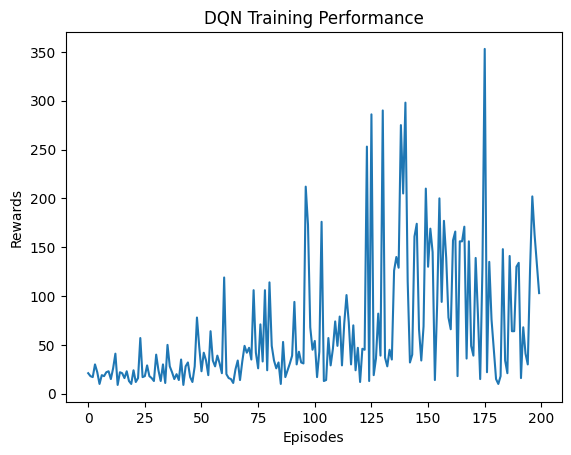

In [13]:
plt.plot(rewards_list)
plt.xlabel("Episodes")
plt.ylabel("Rewards")
plt.title("DQN Training Performance")
plt.show()

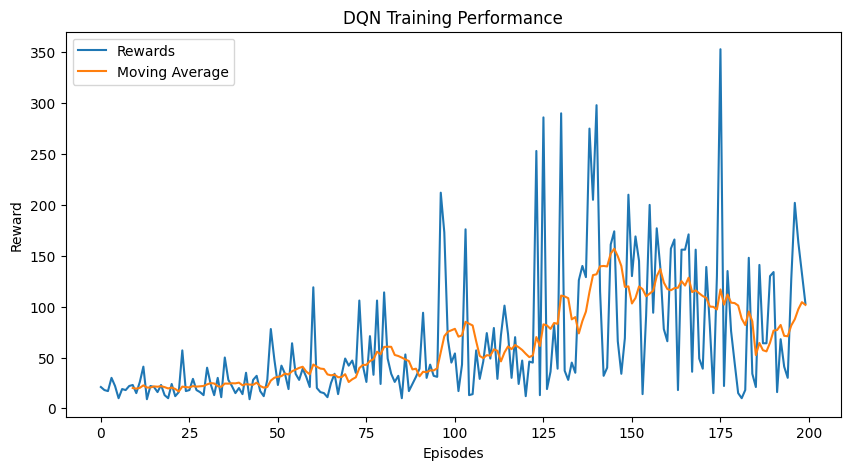

In [14]:
moving_avg = np.convolve(rewards_list, np.ones(10)/10, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(rewards_list, label='Rewards')
plt.plot(range(9, len(rewards_list)), moving_avg, label='Moving Average')
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("DQN Training Performance")
plt.legend()
plt.show()

In [15]:
state, _ = env.reset()
done = False

while not done: 
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    action = torch.argmax(policy_net(state_tensor)).item()
    state, _, done, _, _ = env.step(action)

env.close()

In [16]:
torch.save(policy_net.state_dict(), "dqn_cartpole.pth")
print("Model saved successfully!")

Model saved successfully!
